In [5]:
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn import tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


In [14]:
iris_df=pd.read_csv("Iris.csv")
iris_df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
iris_df.isnull().any()

Id               False
SepalLengthCm    False
SepalWidthCm     False
PetalLengthCm    False
PetalWidthCm     False
Species          False
dtype: bool

In [16]:
iris_df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

In [17]:
iris_df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


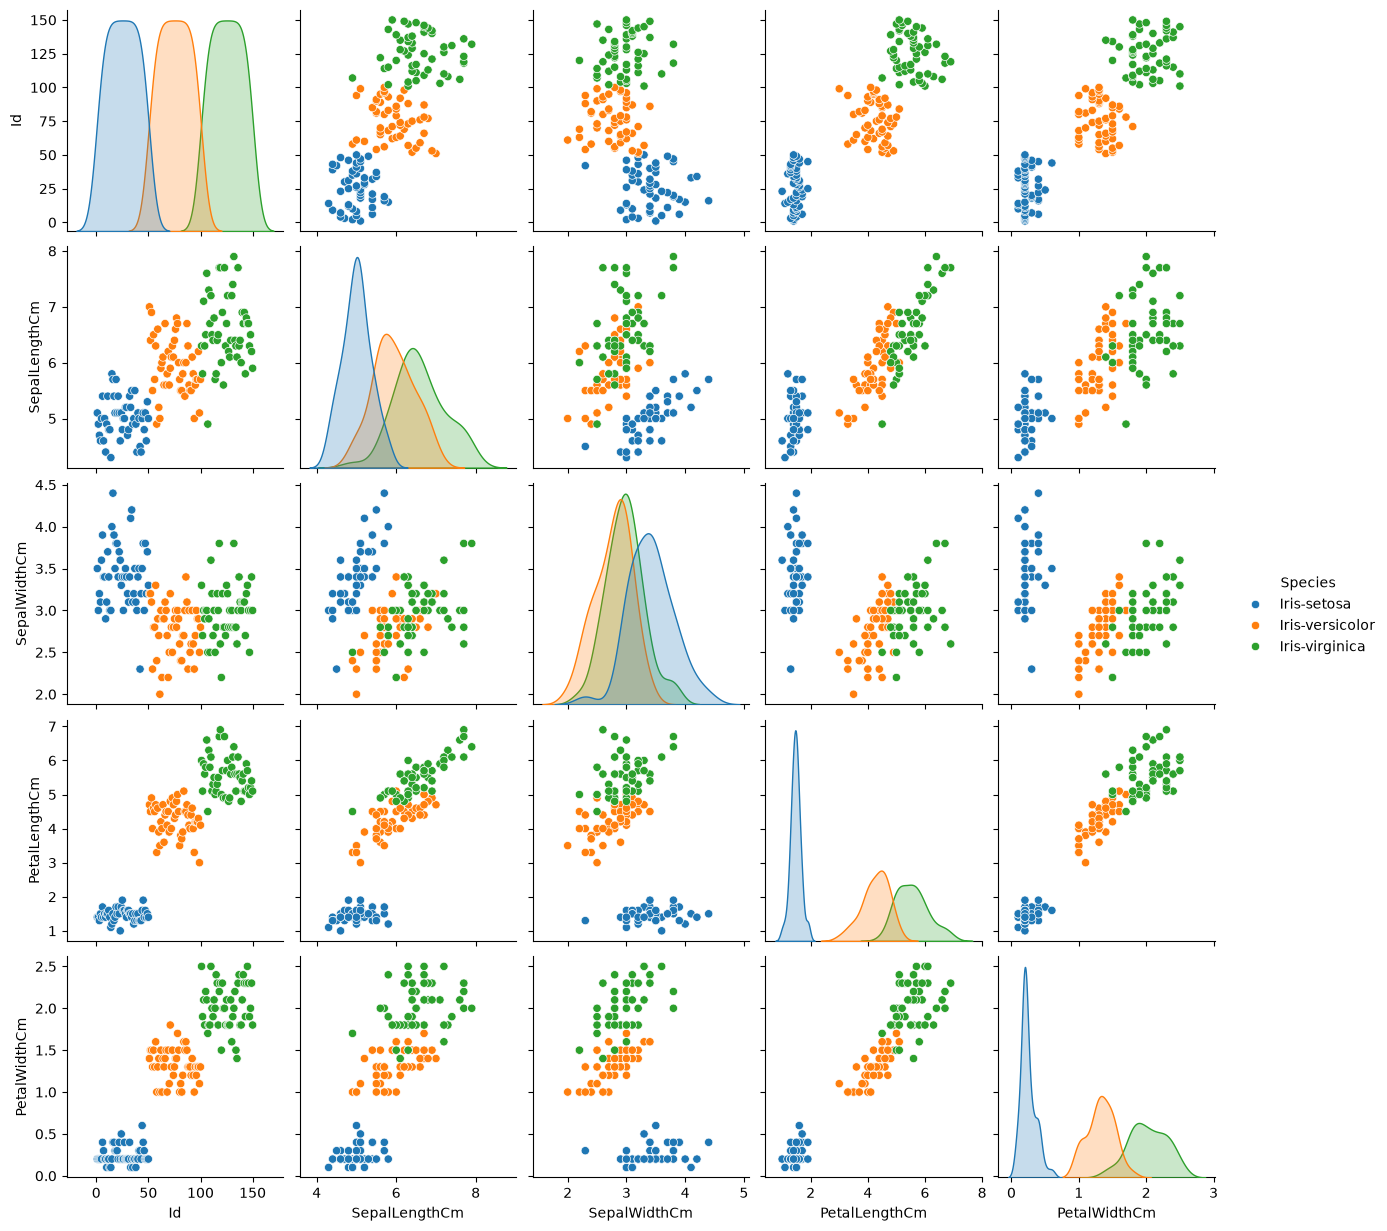

In [20]:
sns.pairplot(iris_df, hue='Species')
plt.savefig("exercise2a.png")
plt.show()

In [33]:
X = iris_df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = iris_df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.9, random_state=1)

In [34]:
clf=tree.DecisionTreeClassifier()
clf=clf.fit(X_train,y_train)

In [35]:
prediction=clf.predict(X_test)
prediction

array(['Iris-setosa', 'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-versicolor', 'Iris-virginica',
       'Iris-setosa', 'Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-setosa', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor'], dtype=object)

In [36]:
print(classification_report(y_test,prediction))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         6
 Iris-virginica       1.00      1.00      1.00         4

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15



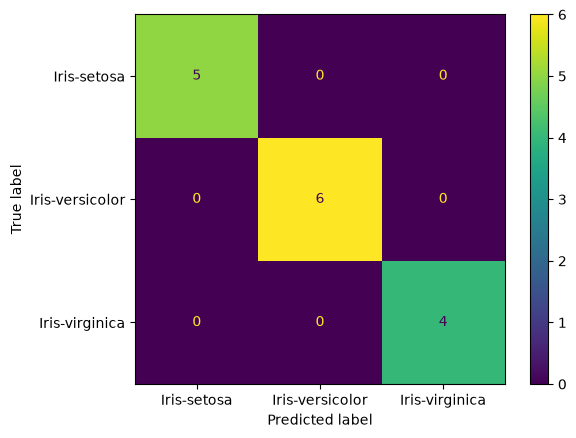

In [38]:
ConfusionMatrixDisplay.from_estimator(clf,X_test,y_test)
plt.savefig("exercise2b.png")
plt.show()

In [39]:
!pip install pydotplus

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24635 sha256=98494337952252ab1069ca257f5751a0cfbbe79d56af021f97e2d7b93d62dd5e
  Stored in directory: /home/ds-lab/.cache/pip/wheels/77/54/7c/c8077b6151c819495492300386cf9b151a954259d1a658c63b
Successfully built pydotplus


In [40]:
!pip install graphviz

In [42]:
import os
os.environ["PATH"]+=os.path.pathsep+r'C:\Program Files|Graphviz\bin'

In [45]:
from io import StringIO
from IPython.display import Image
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier,export_graphviz
import pydotplus

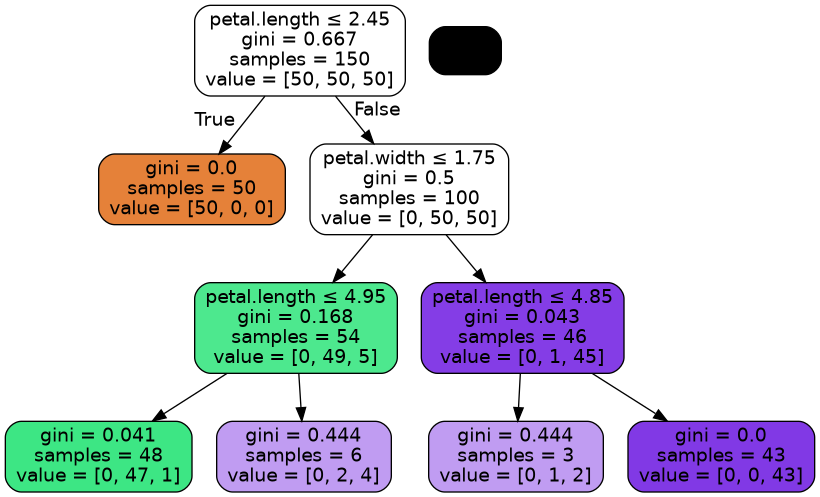

In [46]:
iris = load_iris()
X = iris.data
y = iris.target
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X, y)
dot_data = StringIO()
export_graphviz(clf, out_file=dot_data,
feature_names=['sepal.length', 'sepal.width', 'petal.length', 'petal.width'],
filled=True, rounded=True, special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png("exercise2b.png")
Image(graph.create_png())

In [48]:
SepalLengthCm = 4.8
SepalWidthCm = 2.9
PetalLengthCm = 1.3
PetalWidthCm = 0.2
x = [[SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm]]
res = clf.predict(x)
class_mapping = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
predicted_class = class_mapping[res[0]]
print("The class predicted is --> " + predicted_class)

The class predicted is --> setosa
